In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load the dataset
sales_df = pd.read_csv('sales_data.csv')

# Display the first 5 rows and data info
print(sales_df.head())
print(sales_df.info())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None


In [3]:
# Check for missing values
print(sales_df.isnull().sum())

# Convert Date column to datetime objects
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [4]:
top_products = sales_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)
print("Top 5 Products by Quantity Sold:")
print(top_products)

Top 5 Products by Quantity Sold:
Product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: Quantity, dtype: int64


C:\Users\Bhavendu Pandey\AppData\Local\Temp\ipykernel_4108\2341172102.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Total_Sales', data=sales_df, estimator=sum, ci=None)


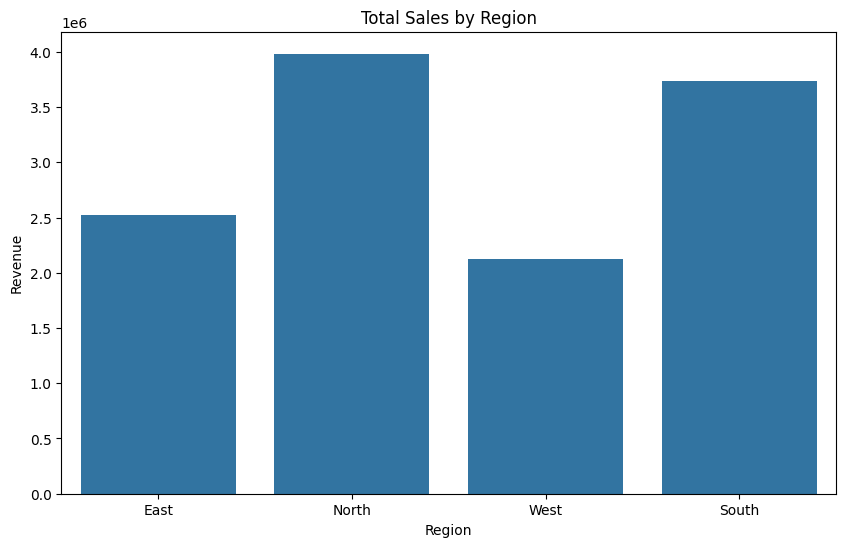

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Total_Sales', data=sales_df, estimator=sum, ci=None)
plt.title('Total Sales by Region')
plt.ylabel('Revenue')
plt.show()

In [6]:
# Load the dataset
house_df = pd.read_csv('house_prices.csv')

# Display basic stats
print(house_df.describe())

             Area    Bedrooms   Bathrooms         Age         Price
count   300.00000  300.000000  300.000000  300.000000  3.000000e+02
mean   2759.70000    3.033333    2.026667   25.000000  2.488366e+07
std    1297.68143    1.467219    0.792495   14.332646  1.266525e+07
min     520.00000    1.000000    1.000000    0.000000  3.695000e+06
25%    1675.75000    2.000000    1.000000   12.000000  1.527750e+07
50%    2738.00000    3.000000    2.000000   25.500000  2.236500e+07
75%    3801.25000    4.000000    3.000000   36.250000  3.460812e+07
max    4999.00000    5.000000    3.000000   49.000000  5.870000e+07


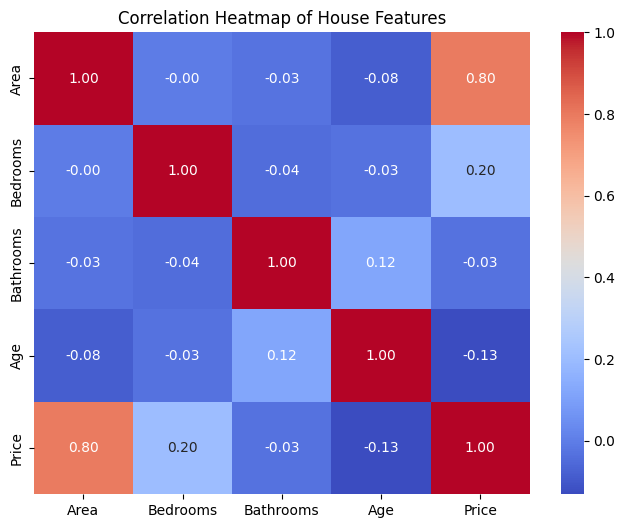

In [7]:
# Select only numeric columns for correlation
numeric_cols = house_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = house_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of House Features')
plt.show()

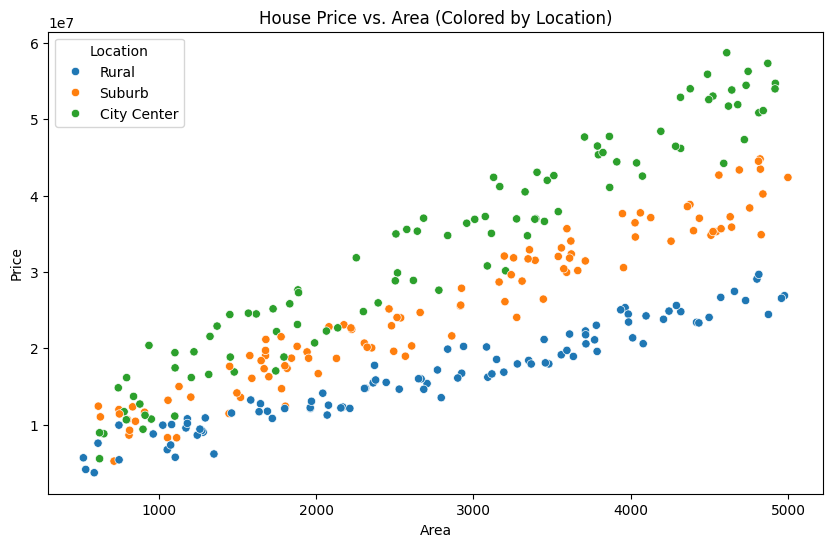

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area', y='Price', data=house_df, hue='Location')
plt.title('House Price vs. Area (Colored by Location)')
plt.show()

Average Price by Location:
Location
City Center    3.314979e+07
Suburb         2.510807e+07
Rural          1.646143e+07
Name: Price, dtype: float64


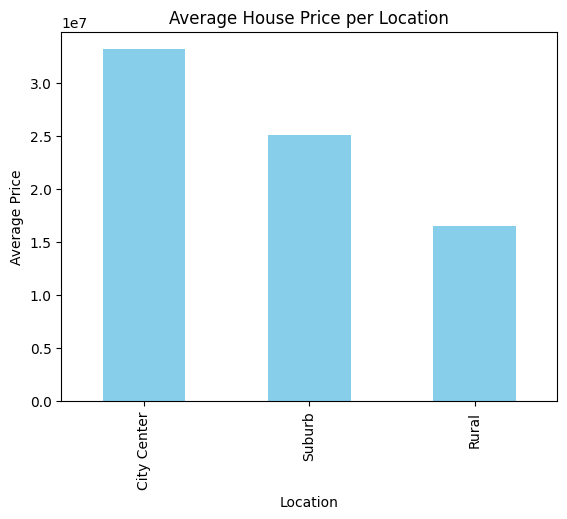

In [9]:
avg_price_location = house_df.groupby('Location')['Price'].mean().sort_values(ascending=False)
print("Average Price by Location:")
print(avg_price_location)

# Optional: Visualize it
avg_price_location.plot(kind='bar', color='skyblue')
plt.ylabel('Average Price')
plt.title('Average House Price per Location')
plt.show()

In [10]:
# Load the dataset
churn_df = pd.read_csv('customer_churn.csv')

# Check for missing values and data types
print(churn_df.isnull().sum())
print(churn_df.info())

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
None


C:\Users\Bhavendu Pandey\AppData\Local\Temp\ipykernel_4108\1216812825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=churn_df, palette='viridis')


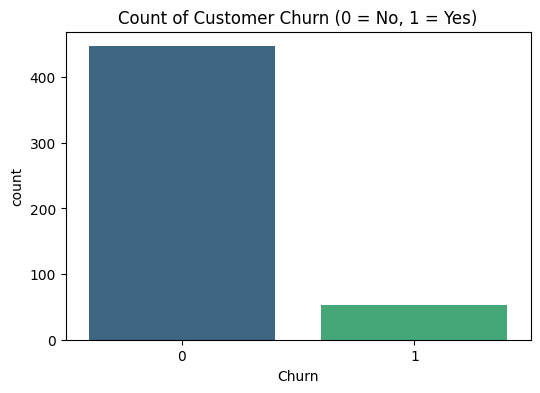

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=churn_df, palette='viridis')
plt.title('Count of Customer Churn (0 = No, 1 = Yes)')
plt.show()

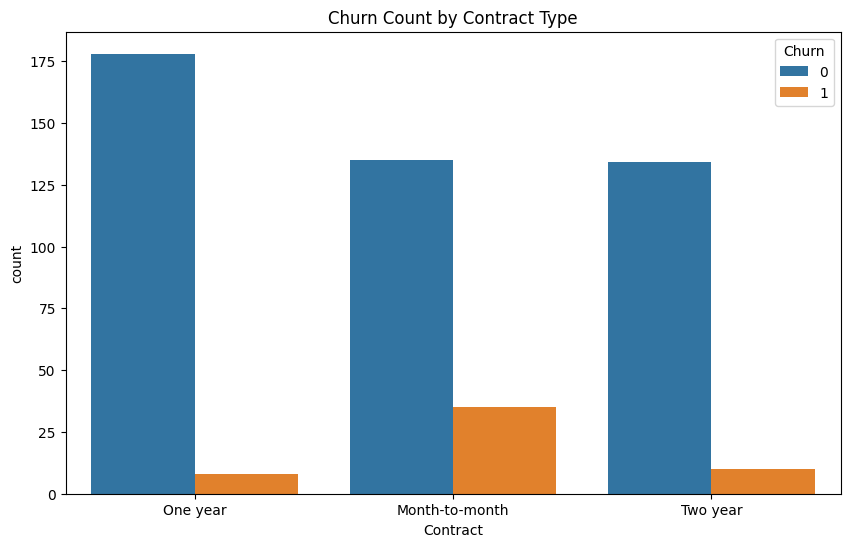

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=churn_df)
plt.title('Churn Count by Contract Type')
plt.show()

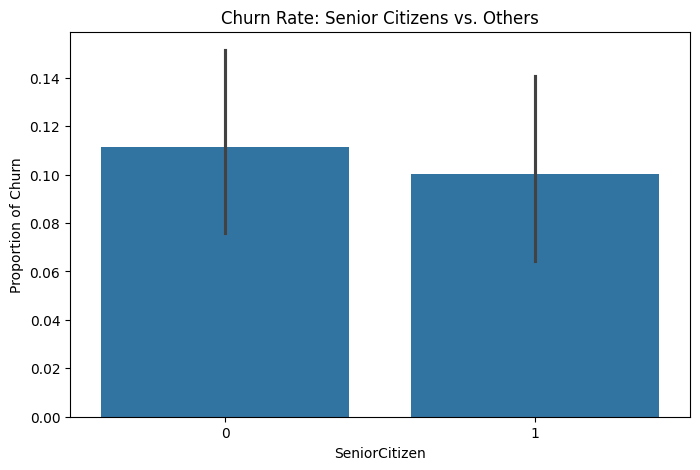

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x='SeniorCitizen', y='Churn', data=churn_df)
plt.title('Churn Rate: Senior Citizens vs. Others')
plt.ylabel('Proportion of Churn')
plt.show()

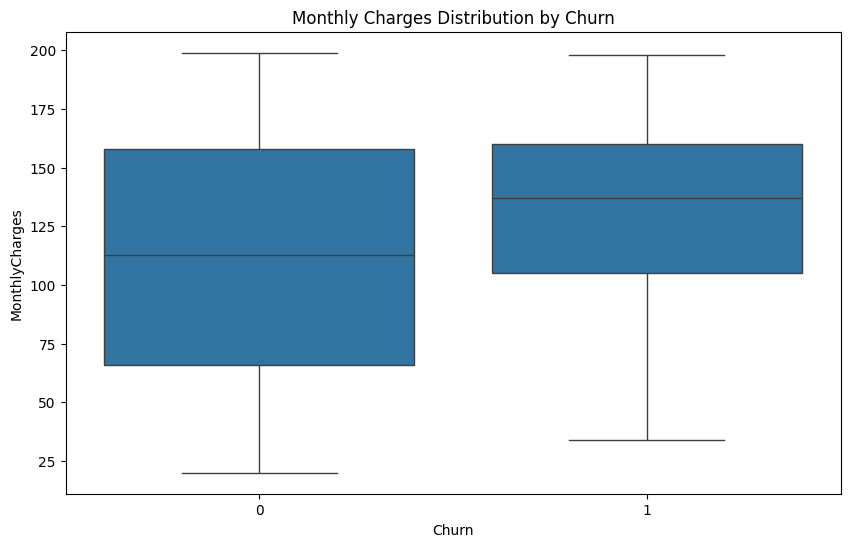

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_df)
plt.title('Monthly Charges Distribution by Churn')
plt.show()